In [3]:
import numpy as np #для матричных вычислений
import pandas as pd #для анализа и предобработки данных
import matplotlib.pyplot as plt #для визуализации
import seaborn as sns #для визуализации

from sklearn import metrics #метрики
from sklearn import model_selection #методы разделения и валидации
from sklearn import ensemble #ансамбли

plt.style.use(r"C:\Users\aleks\Downloads\online_shoppers_intention\online_shoppers_intention.csv") #стиль отрисовки seaborn
%matplotlib inline

Missing colon in file 'C:\\Users\\aleks\\Downloads\\online_shoppers_intention\\online_shoppers_intention.csv', line 1 ('Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue')
Missing colon in file 'C:\\Users\\aleks\\Downloads\\online_shoppers_intention\\online_shoppers_intention.csv', line 2 ('0,0,0,0,1,0,0.2,0.2,0,0,Feb,1,1,1,1,Returning_Visitor,FALSE,FALSE')
Missing colon in file 'C:\\Users\\aleks\\Downloads\\online_shoppers_intention\\online_shoppers_intention.csv', line 3 ('0,0,0,0,2,64,0,0.1,0,0,Feb,2,2,1,2,Returning_Visitor,FALSE,FALSE')
Missing colon in file 'C:\\Users\\aleks\\Downloads\\online_shoppers_intention\\online_shoppers_intention.csv', line 4 ('0,0,0,0,1,0,0.2,0.2,0,0,Feb,4,1,9,3,Returning_Visitor,FALSE,FALSE')
Missing colon in file 'C:\\Users\\aleks\\Downloads\\online_shoppers_intention\

In [5]:
shoppers_data = pd.read_csv(r"C:\Users\aleks\Downloads\online_shoppers_intention\online_shoppers_intention.csv")
shoppers_data.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [6]:
print(shoppers_data.shape)

## (12330, 18)

(12330, 18)


In [7]:
shoppers_data.isna().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

In [8]:
dummy_data = pd.get_dummies(shoppers_data)
dummy_data.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_New_Visitor,VisitorType_Other,VisitorType_Returning_Visitor
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,False,False,False,False,False,False,False,False,False,True
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,...,False,False,False,False,False,False,False,False,False,True
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,False,False,False,False,False,False,False,False,False,True
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,...,False,False,False,False,False,False,False,False,False,True
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,...,False,False,False,False,False,False,False,False,False,True


C:\Users\aleks\AppData\Local\Temp\ipykernel_23788\3825417070.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Revenue', data=dummy_data, palette='CMRmap')
C:\Users\aleks\AppData\Local\Temp\ipykernel_23788\3825417070.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print('Sessions without purchase : {:.2f}%'.format(class_percent[0]))
C:\Users\aleks\AppData\Local\Temp\ipykernel_23788\3825417070.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print('Session

Sessions without purchase : 84.53%
Sessions with purchase: 15.47%


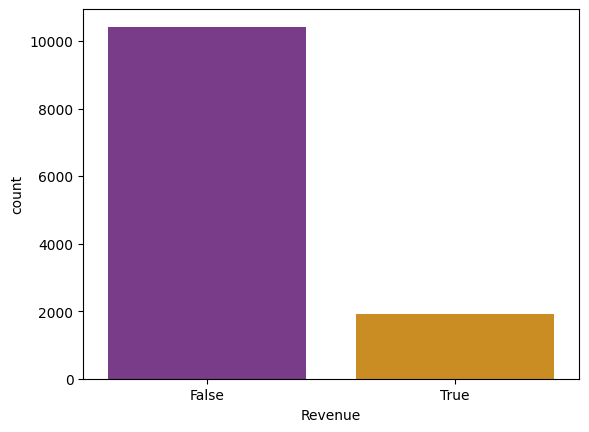

In [9]:
sns.countplot(x='Revenue', data=dummy_data, palette='CMRmap')
class_percent = dummy_data['Revenue'].value_counts(normalize=True) * 100
print('Sessions without purchase : {:.2f}%'.format(class_percent[0]))
print('Sessions with purchase: {:.2f}%'.format(class_percent[1]))

In [10]:
X, y = dummy_data.drop('Revenue', axis=1), dummy_data['Revenue']

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(len(X_train))
print(len(X_test))

9864
2466


In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate

model = RandomForestClassifier(random_state=42)

cv = StratifiedKFold(n_splits=5, shuffle=False)

scores = cross_validate(
    model,
    X_train,
    y_train,
    cv=cv,
    scoring='roc_auc',
    return_train_score=True
)

print(round(scores['train_score'].mean(), 2))
print(round(scores['test_score'].mean(), 2))

1.0
0.93


In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

model = RandomForestClassifier(max_depth=7, n_estimators=200, min_samples_leaf=5, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_train)

print("Accuracy:", round(accuracy_score(y_train, y_pred), 2))
print(classification_report(y_train, y_pred))

Accuracy: 0.92
              precision    recall  f1-score   support

       False       0.93      0.98      0.95      8338
        True       0.86      0.57      0.68      1526

    accuracy                           0.92      9864
   macro avg       0.89      0.78      0.82      9864
weighted avg       0.92      0.92      0.91      9864



In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import precision_recall_curve

model = RandomForestClassifier(
    max_depth=7,
    n_estimators=200,
    min_samples_leaf=5,
    random_state=42
)

cv = StratifiedKFold(n_splits=5, shuffle=False)

proba = cross_val_predict(
    model,
    X_train,
    y_train,
    cv=cv,
    method='predict_proba'
)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_train, proba)
f1 = 2 * precision * recall / (precision + recall + 1e-12)

best_idx = np.argmax(f1)
best_threshold = thresholds[best_idx] if best_idx < len(thresholds) else 1.0

print(round(best_threshold, 2))

0.36


In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import precision_recall_curve, accuracy_score, classification_report
import numpy as np

model = RandomForestClassifier(
    max_depth=7,
    n_estimators=200,
    min_samples_leaf=5,
    random_state=42
)

cv = StratifiedKFold(n_splits=5, shuffle=False)

# вероятности положительного класса
y_proba = cross_val_predict(
    model,
    X_train,
    y_train,
    cv=cv,
    method='predict_proba'
)[:, 1]

# подбор порога по максимуму F1
precision, recall, thresholds = precision_recall_curve(y_train, y_proba)
f1 = 2 * precision * recall / (precision + recall + 1e-12)
best_idx = np.argmax(f1)
threshold = thresholds[best_idx] if best_idx < len(thresholds) else 1.0

# предсказания по выбранному порогу
y_pred_thr = (y_proba >= threshold).astype(int)

print("threshold =", round(threshold, 2))
print("Accuracy:", round(accuracy_score(y_train, y_pred_thr), 2))
print(classification_report(y_train, y_pred_thr, target_names=["False", "True"]))

threshold = 0.36
Accuracy: 0.9
              precision    recall  f1-score   support

       False       0.95      0.93      0.94      8338
        True       0.66      0.72      0.69      1526

    accuracy                           0.90      9864
   macro avg       0.81      0.83      0.82      9864
weighted avg       0.90      0.90      0.90      9864

